In [9]:
import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [10]:
GPT_CONFIG_124M = {
        "vocab_size": 50257,     # Vocabulary size
        "context_length": 1024,  # Context length
        "emb_dim": 768,          # Embedding dimension
        "n_heads": 12,           # Number of attention heads
        "n_layers": 12,          # Number of layers
        "drop_rate": 0.1,        # Dropout rate
        "qkv_bias": False        # Query-Key-Value bias
    }


In [11]:


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

    def create_dataloader_v1(txt, batch_size=4, max_length=256,stride=128, shuffle=True, drop_last=True, num_workers=0):
    # Initialize the tokenizer
        tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
        dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

        return dataloader 



$$\text{Iterations} = \left\lfloor \frac{\text{len}(\text{data}) - \text{max\_length}}{\text{stride}} \right\rfloor + 1$$

DataLoader Batches per Epoch:$$\text{Iterations per Epoch} = \left\lceil \frac{\text{Total Samples}}{\text{Batch Size}} \right\rceil$$

In [12]:

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False, max_seq_len=None, window_size=None):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

        self.max_seq_len = max_seq_len or context_length
        self.window_size = window_size or self.max_seq_len
        self.register_buffer("cache_k", None, persistent=False)
        self.register_buffer("cache_v", None, persistent=False)

    def forward(self, x, use_cache=False):
        b, num_tokens, d_in = x.shape
        keys_new = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries_new = self.W_query(x)
        values_new = self.W_value(x)

        if use_cache:
            # to prevent self.ptr_cur became negative
            assert num_tokens <= self.window_size, (
                f"Input chunk size ({num_tokens}) exceeds KV cache window size ({self.window_size}). "
            )

        #Instead of performing a single massive multihead calculation, tokens are divided into batches each of size head_dim
        keys = keys_new.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values_new.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries_new.view(b, num_tokens, self.num_heads, self.head_dim)

        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        if use_cache:
            if self.cache_k is None or self.cache_k.size(0) != b:
                self.cache_k = torch.zeros(b, self.num_heads,
                                           self.window_size, self.head_dim,
                                           device=x.device)
                self.cache_v = torch.zeros_like(self.cache_k)
                self.ptr_cur = 0  # pointer to next free slot

            # if incoming chunk would overflow discard oldest tokens
            if self.ptr_cur + num_tokens > self.window_size:
                overflow = self.ptr_cur + num_tokens - self.window_size
                # shift everything left by `overflow` (cheap view-copy)
                self.cache_k[:, :, :-overflow, :] = self.cache_k[:, :, overflow:, :].clone()
                self.cache_v[:, :, :-overflow, :] = self.cache_v[:, :, overflow:, :].clone()
                self.ptr_cur -= overflow  # pointer after shift

            self.cache_k[:, :, self.ptr_cur:self.ptr_cur + num_tokens, :] = keys_new
            self.cache_v[:, :, self.ptr_cur:self.ptr_cur + num_tokens, :] = values_new
            self.ptr_cur += num_tokens

            keys = self.cache_k[:, :, :self.ptr_cur, :]
            values = self.cache_v[:, :, :self.ptr_cur, :]
        else:
            keys, values = keys_new, values_new
            self.ptr_cur = 0 

        #QK^T
        attn_scores = queries @ keys.transpose(2, 3)
        K = attn_scores.size(-1)

        if num_tokens == K:
            # No cache → use the pre‑baked triangular mask slice
            causal_mask = torch.triu(torch.ones(num_tokens, K, device=x.device, dtype=torch.bool), diagonal=1)
        else:
            # Cached: need to offset the diagonal by (K − num_tokens)
            offset = K - num_tokens  # number of tokens already in cache before this chunk
            row_idx = torch.arange(num_tokens, device=x.device).unsqueeze(1)  # (num_tokens, 1)
            col_idx = torch.arange(K, device=x.device).unsqueeze(0)           # (1, K)
            causal_mask = row_idx + offset < col_idx                          # True where j > i+offset

          # Original mask truncated to the number of tokens and converted to boolean
        # 1. Slice and apply causal mask
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores = attn_scores.masked_fill(mask_bool, float("-inf")) # <-- Add this!

        # 2. Scale & Softmax
        attn_weights = torch.softmax(attn_scores / (keys.shape[-1] ** 0.5), dim=-1)
        attn_weights = self.dropout(attn_weights)

        # 3. Compute Attention & Transpose back
        context_vec = (attn_weights @ values).transpose(1, 2) # Assumes attn_weights and values are (b, num_heads, ...)

        # 4. Flatten & Project
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)

        return context_vec
    def reset_cache(self):
        self.cache_k, self.cache_v = None, None

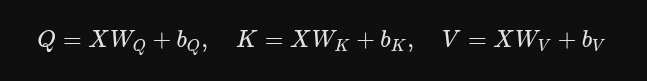

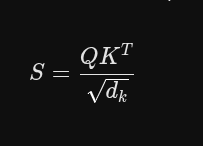            formula for single attention head 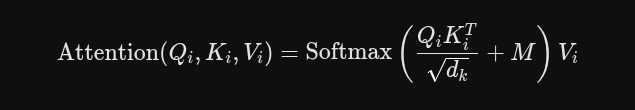

Casual Masking  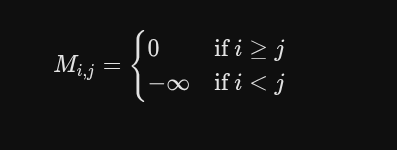   attention weights 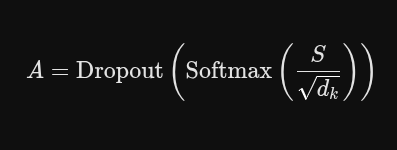


In [13]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

MEAN: 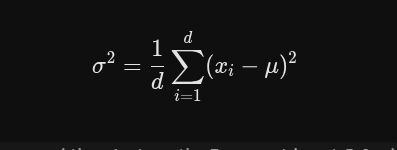

VARIANCE: 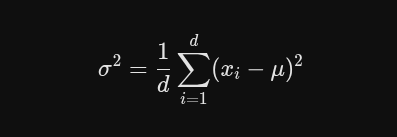

STANDARDIZATION:  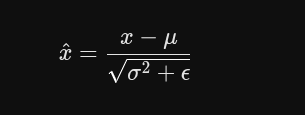

FINAL WORKFLOW:

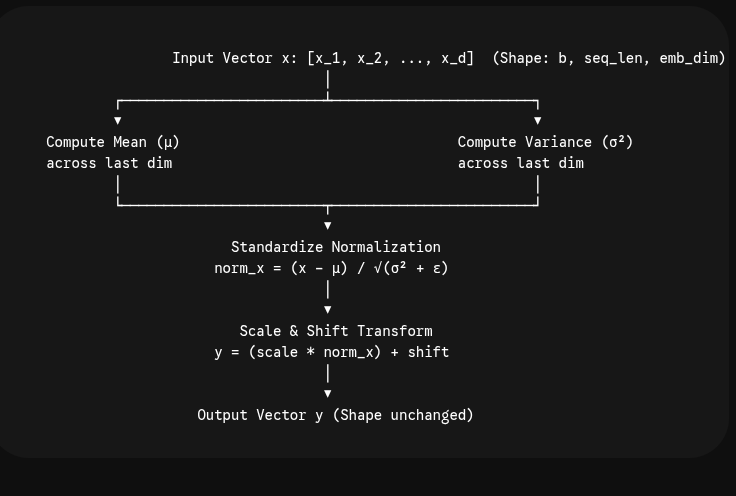

In [14]:
#Gaussian Error Linear Unit
#GELU is used to optimize output in every iteration at end of each layer to overcome dying relu problem 
#RELU has a drawback of identification of negative problems, due to which it strict give 0.0 at x < 0 and neuron weights become noise.
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


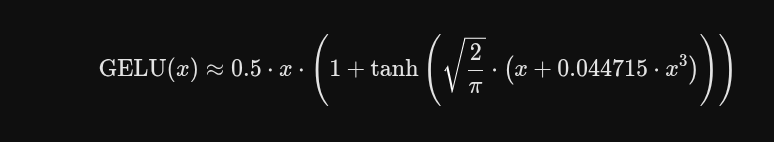

In [15]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [16]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]) #decides wether neuron weight of qkv has bias vector
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])


#Addition of Residual Connection to overcome Vanishing Gradient problem and Information Degradtion, by pre-weights of pervious iteration for next block
    def forward(self, x, use_cache=False):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x, use_cache = use_cache)   # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

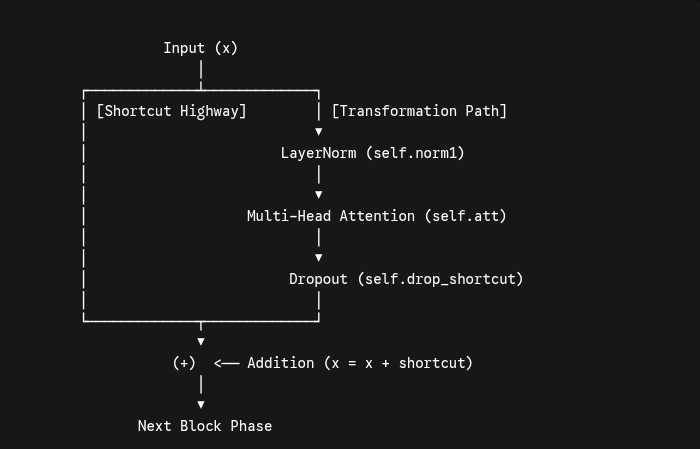

In [17]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.ModuleList(
            [TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.ptr_current_pos = 0
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx, use_cache = False):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        if use_cache:
            context_length = self.pos_emb.num_embeddings
            # to prevent generate more sequence than context_length
            # since longer than context_length will cause model out of bound error when reading the position embedding
            assert self.ptr_current_pos + seq_len <= context_length, (
                f"Position embedding overflow. Want to read {self.ptr_current_pos + seq_len} which excceded size of {context_length}"
            )
            pos_ids = torch.arange(self.ptr_current_pos, self.ptr_current_pos + seq_len, device=in_idx.device, dtype=torch.long)
            self.ptr_current_pos += seq_len
        else:
            pos_ids = torch.arange(0, seq_len, device=in_idx.device, dtype=torch.long)
        pos_embeds = self.pos_emb(pos_ids).unsqueeze(0)
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        for blk in self.trf_blocks:
            x = blk(x, use_cache=use_cache)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

    def reset_kv_cache(self):
        for blk in self.trf_blocks:
            blk.att.reset_cache()
        self.ptr_current_pos = 0

In [18]:
def generate_text_simple_cached(model, idx, max_new_tokens, context_size=None, use_cache=True):
    model.eval()

    ctx_len = context_size or model.pos_emb.num_embeddings
    kv_window_size = model.kv_window_size

    with torch.no_grad():
        if use_cache:
            model.reset_kv_cache()

            input_tokens = idx[:, -ctx_len:]
            input_tokens_length = input_tokens.size(1)

            # prefill to handle input_tokens_length > kv_window_size
            for i in range(0, input_tokens_length, kv_window_size):
                chunk = input_tokens[:, i:i+kv_window_size]
                logits = model(chunk, use_cache=True)

            # can't generate more than ctx_len of result
            # due to the limitation of position embedding
            max_generable = ctx_len - input_tokens_length
            max_new_tokens = min(max_new_tokens, max_generable)

            for _ in range(max_new_tokens):
                next_idx = logits[:, -1].argmax(dim=-1, keepdim=True)
                idx = torch.cat([idx, next_idx], dim=1)
                logits = model(next_idx, use_cache=True)
        else:
            for _ in range(max_new_tokens):
                logits = model(idx[:, -ctx_len:], use_cache=False)
                next_idx = logits[:, -1].argmax(dim=-1, keepdim=True)
                idx = torch.cat([idx, next_idx], dim=1)

    return idx

In [19]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
  )
  (final_norm): LayerNorm()
  (out_head): Linear(in_features=768, out_features=50257